# Online News Popularity Prediction 

## Problem Statement

The goal of this project is to analyze and predict the popularity of online news articles using machine learning techniques. The problem is divided into two tasks:

### 1️ Predict Whether an Article Will Go Viral (Classification)

- **Objective**: Classify whether a news article will go *viral* or *not viral* based on its features.
- **Definition of Viral**: An article is considered *viral* if it exceeds a certain threshold of total shares.
- **Type of Task**: Binary Classification

### 2️ Predict the Exact Number of Shares (Regression)

- **Objective**: Estimate the **exact number of shares** an article will receive.
- **Type of Task**: Regression
- **Use Case**: Helps understand the factors driving share counts and forecast article reach more precisely.


## Data Loading and Initial Exploration

### Load the libraries

In [374]:
# 1. IMPORT LIBRARIES

# Basic libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Machine learning libraries
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                           mean_absolute_error, mean_squared_error, r2_score, roc_auc_score)

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier

# Regression models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.dummy import DummyRegressor

# Advanced models
import xgboost as xgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Ignore warnings for cleaner output
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")


All libraries imported successfully!


### Load the data

In [376]:
# Load the dataset
df= pd.read_csv('C:\\DocsSahi\\UE\\sem2\\machineLearning\\Final Project\\OnlineNewsPopularity.csv')
print(f" Dataset shape: {df. shape[0]} rows × {df. shape[1]} columns")

 Dataset shape: 39644 rows × 61 columns


## STEP 1: Data Analysis

### Show the first 5 rows

In [379]:
# Display first few rows
df.columns = df.columns.str.strip()
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


### Display all the column names

In [381]:
# Display column names
print(f" Column names ({len(df.columns)} total):")
for i, col in enumerate(df.columns):
    print(f"{i+1:2d}. {col}")

 Column names (61 total):
 1. url
 2. timedelta
 3. n_tokens_title
 4. n_tokens_content
 5. n_unique_tokens
 6. n_non_stop_words
 7. n_non_stop_unique_tokens
 8. num_hrefs
 9. num_self_hrefs
10. num_imgs
11. num_videos
12. average_token_length
13. num_keywords
14. data_channel_is_lifestyle
15. data_channel_is_entertainment
16. data_channel_is_bus
17. data_channel_is_socmed
18. data_channel_is_tech
19. data_channel_is_world
20. kw_min_min
21. kw_max_min
22. kw_avg_min
23. kw_min_max
24. kw_max_max
25. kw_avg_max
26. kw_min_avg
27. kw_max_avg
28. kw_avg_avg
29. self_reference_min_shares
30. self_reference_max_shares
31. self_reference_avg_sharess
32. weekday_is_monday
33. weekday_is_tuesday
34. weekday_is_wednesday
35. weekday_is_thursday
36. weekday_is_friday
37. weekday_is_saturday
38. weekday_is_sunday
39. is_weekend
40. LDA_00
41. LDA_01
42. LDA_02
43. LDA_03
44. LDA_04
45. global_subjectivity
46. global_sentiment_polarity
47. global_rate_positive_words
48. global_rate_negative_words

### Data types summary

In [383]:
# Check data types
print(f"Data types summary:")
print(df.dtypes.value_counts())

Data types summary:
float64    59
object      1
int64       1
Name: count, dtype: int64


## STEP 2: Data Preprocessing

### Identify which columns have missing values

In [385]:
# Check for missing values
missing_values = df.isnull().sum()
print(f"Missing values check:")
if missing_values.sum() == 0:
    print("No missing values found!")
else:
    print(f"Found {missing_values.sum()} missing values")
    print(missing_values[missing_values > 0])

Missing values check:
No missing values found!


### Basic statistics of target variable 'shares'

In [387]:
# Basic statistics of shares
shares = df['shares']
print("Target variable: 'shares' (number of times article was shared)")
print("\nBasic statistics:")
print(shares.describe())


Target variable: 'shares' (number of times article was shared)

Basic statistics:
count     39644.000000
mean       3395.380184
std       11626.950749
min           1.000000
25%         946.000000
50%        1400.000000
75%        2800.000000
max      843300.000000
Name: shares, dtype: float64


In [388]:
print(f"\nAdditional insights:")
print(f"Skewness: { shares.skew():.3f}")
print(f"Kurtosis: { shares.kurtosis():.3f}")
print(f"Articles with 0 shares: {( shares == 0).sum()} ({( shares == 0).mean()*100:.1f}%)")
print(f"Articles with >10k shares: {( shares > 10000).sum()} ({( shares > 10000).mean()*100:.1f}%)")
print(f"Articles with >50k shares: {( shares > 50000).sum()} ({( shares > 50000).mean()*100:.1f}%)")


Additional insights:
Skewness: 33.964
Kurtosis: 1832.673
Articles with 0 shares: 0 (0.0%)
Articles with >10k shares: 2185 (5.5%)
Articles with >50k shares: 203 (0.5%)


### Drop the required coulmns

In [390]:
# Remove URL column (not useful for prediction)
df = df.drop(columns=['url'])
print(" Removed 'url' column")

 Removed 'url' column


## STEP 3: Exploratory Data Analysis

### 1. Visualizing Share Distribution by Percentiles

##### 50th percentile: Median performance
##### 75th percentile: Above-average performance
##### 90th percentile: High performance
##### 95th percentile: Very high performance
#####  99th percentile: Viral content

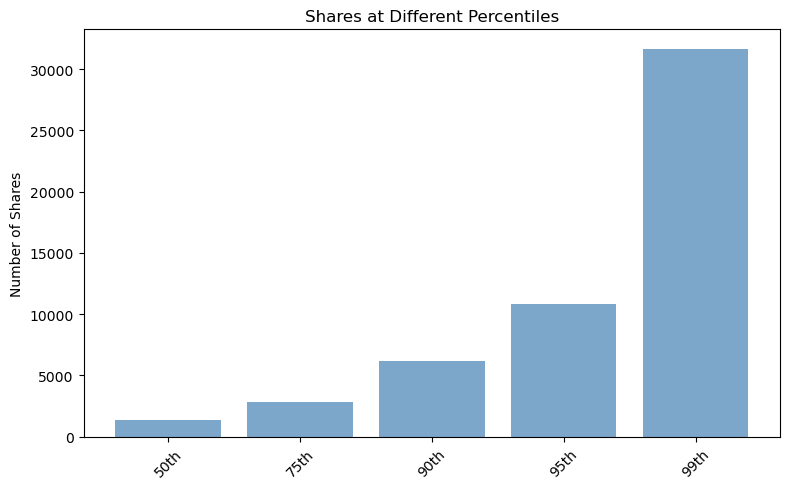

In [392]:
percentiles = [50, 75, 90, 95, 99]
share_percentiles = [np.percentile(df['shares'], p) for p in percentiles]
plt.figure(figsize=(8, 5))
plt.bar([f'{p}th' for p in percentiles], share_percentiles, color='steelblue', alpha=0.7)
plt.title('Shares at Different Percentiles')
plt.ylabel('Number of Shares')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2.  Average Article Shares by Weekday

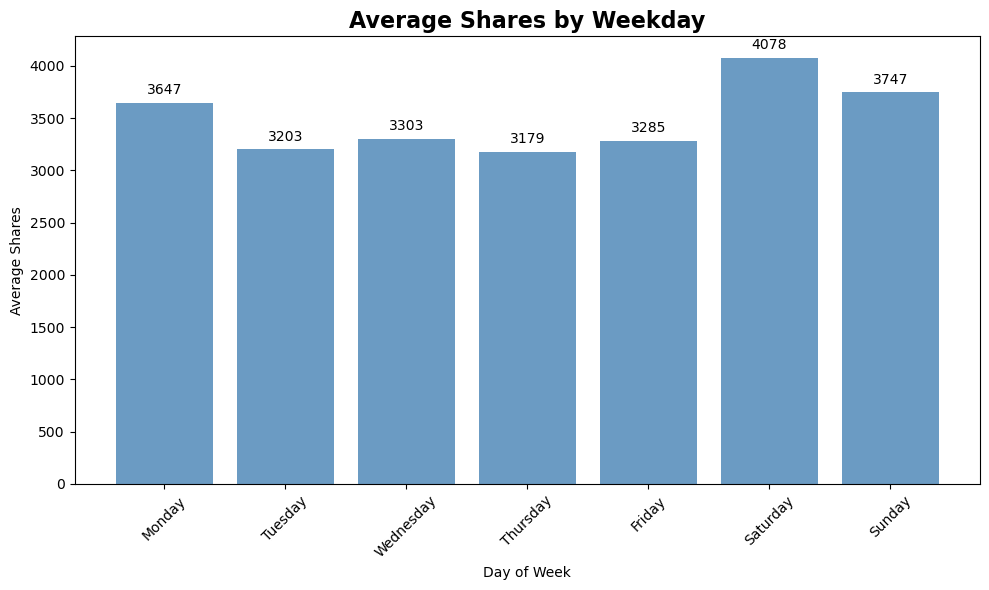

In [394]:
# Shares by Weekday 
weekday_cols = ['weekday_is_monday', 'weekday_is_tuesday', 'weekday_is_wednesday', 
                'weekday_is_thursday', 'weekday_is_friday', 'weekday_is_saturday', 'weekday_is_sunday']
weekday_labels = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

weekday_shares = []
for col in weekday_cols:
    avg_shares = df[df[col] == 1]['shares'].mean()
    weekday_shares.append(avg_shares)

plt.figure(figsize=(10, 6))
bars = plt.bar(weekday_labels, weekday_shares, color='steelblue', alpha=0.8)
plt.title('Average Shares by Weekday', fontsize=16, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Average Shares')
plt.xticks(rotation=45)

# Add value labels on bars
for bar, value in zip(bars, weekday_shares):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             f'{value:.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

### 3. Weekend vs. Weekday Share Analysis

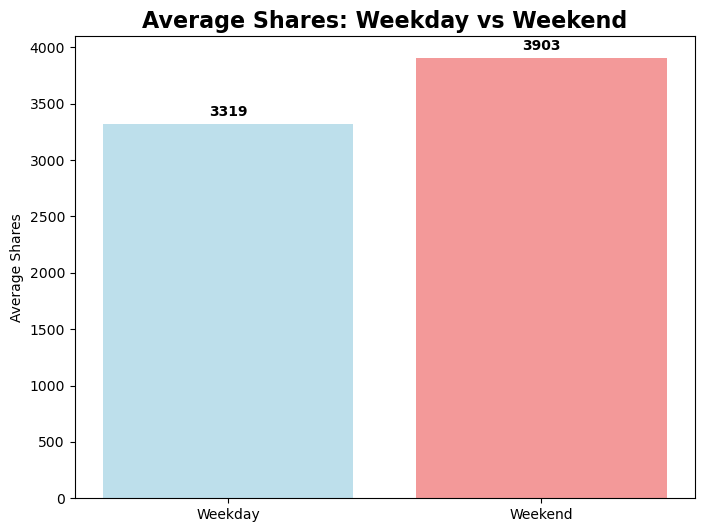

In [396]:
# Weekend vs Weekday Analysis
weekend_shares = df[df['is_weekend'] == 1]['shares'].mean()
weekday_shares = df[df['is_weekend'] == 0]['shares'].mean()

plt.figure(figsize=(8, 6))
categories = ['Weekday', 'Weekend']
values = [weekday_shares, weekend_shares]
bars = plt.bar(categories, values, color=['lightblue', 'lightcoral'], alpha=0.8)
plt.title('Average Shares: Weekday vs Weekend', fontsize=16, fontweight='bold')
plt.ylabel('Average Shares')

# Add value labels
for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             f'{value:.0f}', ha='center', va='bottom', fontweight='bold')

plt.show()

### 4. Top Features Correlated with Article Shares

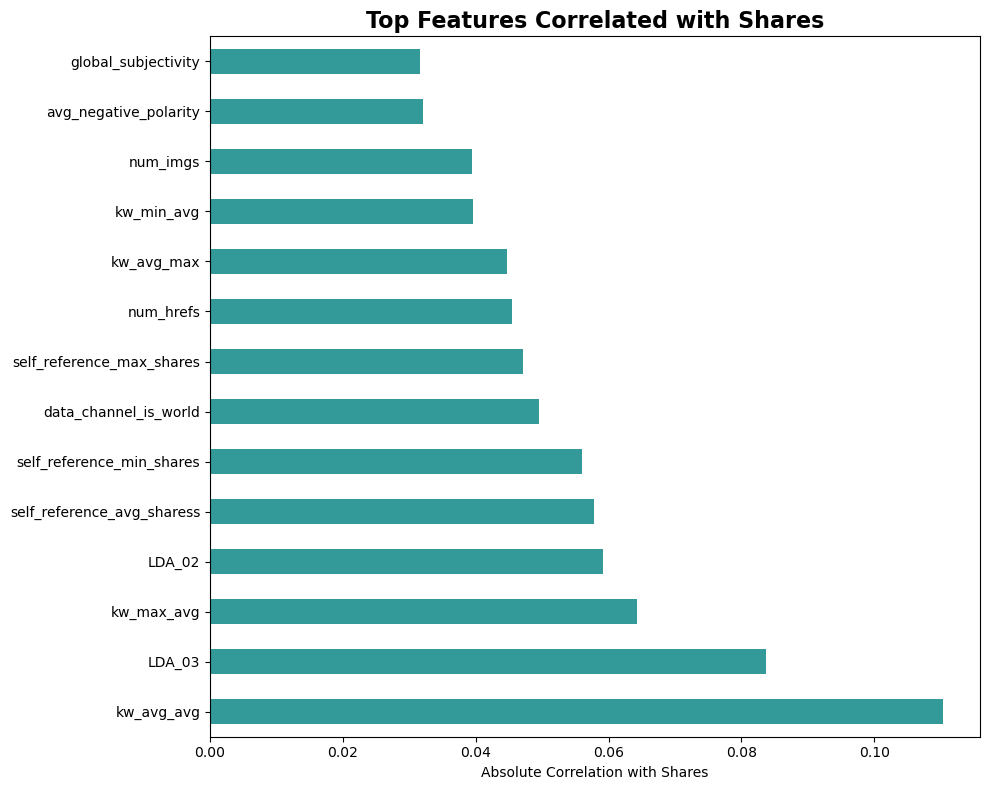

In [398]:
# Top Features Correlation with Shares
shares_corr = df.corr()['shares'].abs().sort_values(ascending=False)
top_features = shares_corr.head(15).drop('shares')  # Exclude shares itself

plt.figure(figsize=(10, 8))
top_features.plot(kind='barh', color='teal', alpha=0.8)
plt.title('Top Features Correlated with Shares', fontsize=16, fontweight='bold')
plt.xlabel('Absolute Correlation with Shares')
plt.tight_layout()
plt.show()

### 5. Content and Media Length Analysis

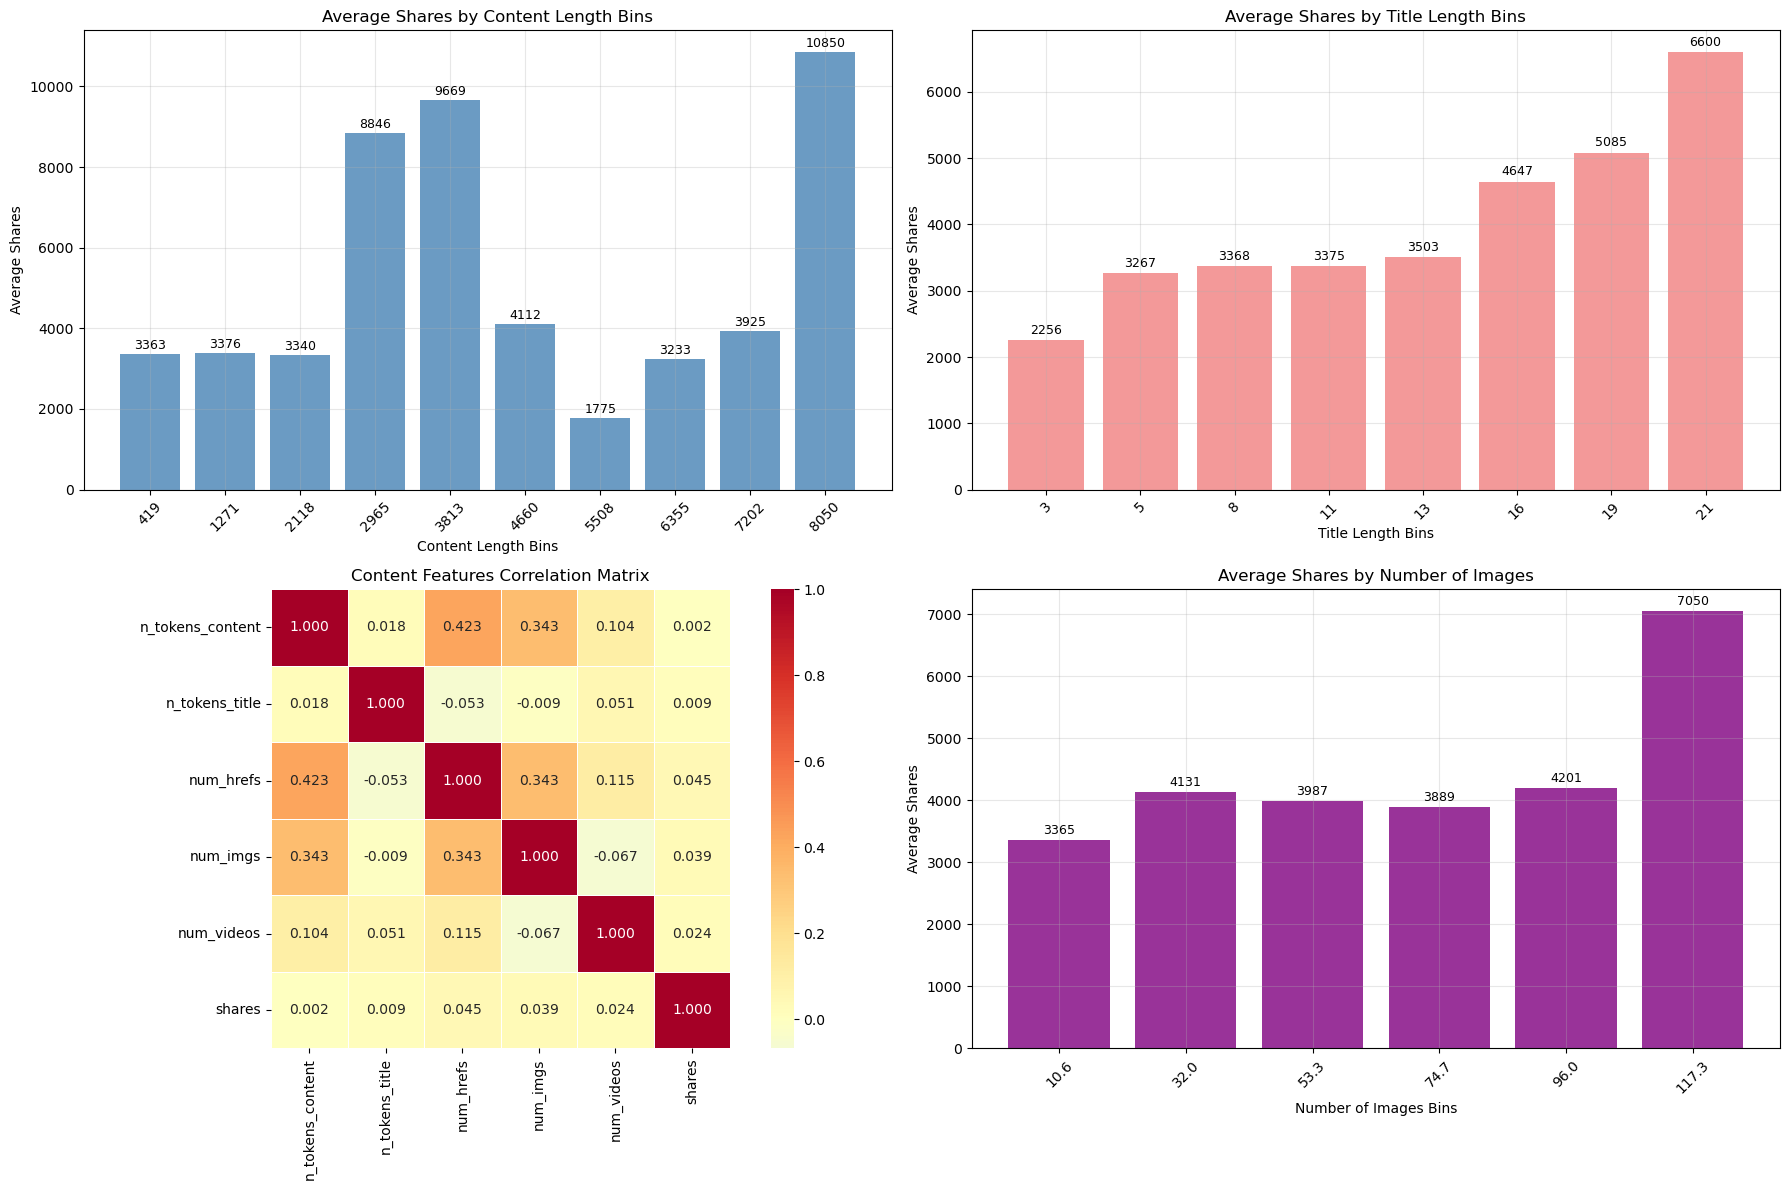

In [400]:
# Content Length Analysis
fig = plt.figure(figsize=(18, 12))

# Binned analysis for content length
plt.subplot(2, 2, 1)
content_bins = pd.cut(df['n_tokens_content'], bins=10)
binned_shares = df.groupby(content_bins)['shares'].mean()
bin_centers = [interval.mid for interval in binned_shares.index]
bars = plt.bar(range(len(binned_shares)), binned_shares.values, color='steelblue', alpha=0.8)
plt.xlabel('Content Length Bins')
plt.ylabel('Average Shares')
plt.title('Average Shares by Content Length Bins')
plt.xticks(range(len(binned_shares)), [f'{int(x)}' for x in bin_centers], rotation=45)
for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             f'{binned_shares.values[i]:.0f}', ha='center', va='bottom', fontsize=9)
plt.grid(True, alpha=0.3)

# Binned analysis for title length
plt.subplot(2, 2, 2)
title_bins = pd.cut(df['n_tokens_title'], bins=8)
binned_title_shares = df.groupby(title_bins)['shares'].mean()
bin_centers_title = [interval.mid for interval in binned_title_shares.index]
bars = plt.bar(range(len(binned_title_shares)), binned_title_shares.values, color='lightcoral', alpha=0.8)
plt.xlabel('Title Length Bins')
plt.ylabel('Average Shares')
plt.title('Average Shares by Title Length Bins')
plt.xticks(range(len(binned_title_shares)), [f'{int(x)}' for x in bin_centers_title], rotation=45)
for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             f'{binned_title_shares.values[i]:.0f}', ha='center', va='bottom', fontsize=9)
plt.grid(True, alpha=0.3)

# Correlation heatmap of content features
plt.subplot(2, 2, 3)
content_features = ['n_tokens_content', 'n_tokens_title', 'num_hrefs', 'num_imgs', 'num_videos', 'shares']
corr_matrix = df[content_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', center=0, square=True, 
            linewidths=0.5, ax=plt.gca(), fmt='.3f')
plt.title('Content Features Correlation Matrix')

# Images analysis - bar chart by bins
plt.subplot(2, 2, 4)
img_bins = pd.cut(df['num_imgs'], bins=6)
binned_img_shares = df.groupby(img_bins)['shares'].mean()
bin_centers_img = [interval.mid for interval in binned_img_shares.index]
bars = plt.bar(range(len(binned_img_shares)), binned_img_shares.values, color='purple', alpha=0.8)
plt.xlabel('Number of Images Bins')
plt.ylabel('Average Shares')
plt.title('Average Shares by Number of Images')
plt.xticks(range(len(binned_img_shares)), [f'{x:.1f}' for x in bin_centers_img], rotation=45)
for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             f'{binned_img_shares.values[i]:.0f}', ha='center', va='bottom', fontsize=9)
plt.grid(True, alpha=0.3)

plt.tight_layout()  # Adjust spacing
plt.show()


## STEP 4: Feature Engineering

### Determining Threshold for 'Viral' Classification

In [402]:
# Determine thresholds for classification
median_shares = shares.median()
q75_shares = shares.quantile(0.75)
mean_shares = shares.mean()

print(f"\nPotential thresholds for 'viral' classification:")
print(f"Median: {median_shares:.0f} shares (50-50 split)")
print(f"75th percentile: {q75_shares:.0f} shares (25-75 split)")
print(f"Mean: {mean_shares:.0f} shares")

# We'll use median as threshold for balanced classes
viral_threshold = median_shares
print(f"\nSelected threshold: {viral_threshold:.0f} shares (median)")


Potential thresholds for 'viral' classification:
Median: 1400 shares (50-50 split)
75th percentile: 2800 shares (25-75 split)
Mean: 3395 shares

Selected threshold: 1400 shares (median)


## STEP 5: Feature Selection

### Organizing Features by Categories

In [404]:
# FEATURE ANALYSIS BY CATEGORIES

# Define feature categories for better understanding
feature_categories = {
    'content_features': [' n_tokens_title', ' n_tokens_content', ' n_unique_tokens', 
                        ' n_non_stop_words', ' n_non_stop_unique_tokens', ' average_token_length'],
    'temporal_features': [' weekday_is_monday', ' weekday_is_tuesday', ' weekday_is_wednesday', 
                         ' weekday_is_thursday', ' weekday_is_friday', ' weekday_is_saturday', 
                         ' weekday_is_sunday', ' is_weekend', ' timedelta'],
    'channel_features': [' data_channel_is_lifestyle', ' data_channel_is_entertainment', 
                        ' data_channel_is_bus', ' data_channel_is_socmed', 
                        ' data_channel_is_tech', ' data_channel_is_world'],
    'sentiment_features': [' global_subjectivity', ' global_sentiment_polarity', 
                          ' global_rate_positive_words', ' global_rate_negative_words',
                          ' rate_positive_words', ' rate_negative_words', 
                          ' title_subjectivity', ' title_sentiment_polarity'],
    'keyword_features': [' num_keywords', ' kw_min_min', ' kw_max_min', ' kw_avg_min', 
                        ' kw_min_max', ' kw_max_max', ' kw_avg_max'],
    'media_features': [' num_hrefs', ' num_self_hrefs', ' num_imgs', ' num_videos'],
    'lda_features': [' LDA_00', ' LDA_01', ' LDA_02', ' LDA_03', ' LDA_04']
}

# Print feature categories summary
print("Feature categories:")
for category, features in feature_categories.items():
    print(f"{category.upper().replace('_', ' ')}: {len(features)} features")


Feature categories:
CONTENT FEATURES: 6 features
TEMPORAL FEATURES: 9 features
CHANNEL FEATURES: 6 features
SENTIMENT FEATURES: 8 features
KEYWORD FEATURES: 7 features
MEDIA FEATURES: 4 features
LDA FEATURES: 5 features


In [405]:
# Create a copy for preprocessing
df_processed = df.copy()
print(f"Starting preprocessing with {df_processed.shape[0]} rows")

Starting preprocessing with 39644 rows


#### Outlier Removal for 'Shares' Column

In [407]:
# Handle extreme outliers (remove top 1% to reduce noise)
q99 = df_processed['shares'].quantile(0.99)
initial_size = len(df_processed)
df_processed = df_processed[df_processed['shares'] <= q99]
final_size = len(df_processed)
print(f"Removed extreme outliers (>{q99:.0f} shares): {initial_size - final_size} articles removed")

Removed extreme outliers (>31657 shares): 397 articles removed


### Target Variable Creation

In [409]:
# Create target variables

# 1. Binary classification target (viral vs non-viral)
df_processed[' is_viral'] = (df_processed['shares'] >= viral_threshold).astype(int)
viral_distribution = df_processed[' is_viral'].value_counts()
print(f"Binary target 'is_viral' created:")
print(f"  Not viral (0): {viral_distribution[0]} articles ({viral_distribution[0]/len(df_processed)*100:.1f}%)")
print(f"  Viral (1): {viral_distribution[1]} articles ({viral_distribution[1]/len(df_processed)*100:.1f}%)")

Binary target 'is_viral' created:
  Not viral (0): 18490 articles (47.1%)
  Viral (1): 20757 articles (52.9%)


In [410]:
# Keep original shares for regression
print(f"Regression target 'shares' maintained (min: {df_processed['shares'].min()}, max: {df_processed['shares'].max()})")

# Content ratios
df_processed[' title_content_ratio'] = df_processed['n_tokens_title'] / (df_processed['n_tokens_content'] + 1)

# Media richness
df_processed['total_media'] = df_processed['num_imgs'] + df_processed['num_videos']

# Sentiment balance
df_processed['sentiment_balance'] = df_processed['rate_positive_words'] - df_processed['rate_negative_words']

print("Created 3 simple engineered features")

Regression target 'shares' maintained (min: 1, max: 31600)
Created 3 simple engineered features


## STEP 6: Model Development

###  Data Preparation for Modeling

In [412]:
# Prepare features for modeling
target_cols = ['shares', ' is_viral']
exclude_cols = target_cols + (['url'] if 'url' in df_processed.columns else [])
feature_cols = [col for col in df_processed.columns if col not in exclude_cols]

X = df_processed[feature_cols]
y_regression = df_processed['shares']
y_classification = df_processed[' is_viral']

print(f"Final dataset prepared:")
print(f"Features: {X.shape[1]} columns")
print(f"Samples: {X.shape[0]} rows")
print(f"Classification target: {y_classification.value_counts().to_dict()}")
print(f"Regression target range: {y_regression.min():.0f} - {y_regression.max():.0f}")

Final dataset prepared:
Features: 62 columns
Samples: 39247 rows
Classification target: {1: 20757, 0: 18490}
Regression target range: 1 - 31600


### Train-Test Split and Data Standardization

In [414]:
# TRAIN-TEST SPLIT

# Split data for both classification and regression
# Use stratification for classification to maintain class balance
X_train, X_test, y_class_train, y_class_test = train_test_split(
    X, y_classification, test_size=0.2, random_state=42, stratify=y_classification
)

# For regression, use the same split indices
_, _, y_reg_train, y_reg_test = train_test_split(
    X, y_regression, test_size=0.2, random_state=42, stratify=y_classification
)

print(f"Data split completed:")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Feature dimensions: {X_train.shape[1]}")

# Check class balance in splits
print(f"\nClassification target balance:")
print(f"Training set: {pd.Series(y_class_train).value_counts().to_dict()}")
print(f"Test set: {pd.Series(y_class_test).value_counts().to_dict()}")

# Feature scaling (important for some algorithms)


# StandardScaler for algorithms sensitive to scale (SVM, Neural Networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Data split completed:
Training set: 31397 samples
Test set: 7850 samples
Feature dimensions: 62

Classification target balance:
Training set: {1: 16605, 0: 14792}
Test set: {1: 4152, 0: 3698}


### Baseline Model

#### 1. Logistic Regression Classifier

In [416]:
# BASELINE CLASSIFICATION MODEL

# Dictionary to store all classification results
classification_results = {}

# Logistic Regression classifier

log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_class_train)
log_reg_pred = log_reg.predict(X_test_scaled)
log_reg_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

log_reg_accuracy = accuracy_score(y_class_test, log_reg_pred)
log_reg_auc = roc_auc_score(y_class_test, log_reg_prob)
classification_results['Logistic Regression'] = log_reg_accuracy

print(f"Accuracy: {log_reg_accuracy:.4f}")
print(f"ROC-AUC: {log_reg_auc:.4f}")
print("Classification Report:")
print(classification_report(y_class_test, log_reg_pred, target_names=['Not Viral', 'Viral']))

Accuracy: 0.6571
ROC-AUC: 0.7084
Classification Report:
              precision    recall  f1-score   support

   Not Viral       0.64      0.61      0.63      3698
       Viral       0.67      0.70      0.68      4152

    accuracy                           0.66      7850
   macro avg       0.66      0.65      0.65      7850
weighted avg       0.66      0.66      0.66      7850



### Advanced Classification Models

#### 1. Random Forest Classifier

In [418]:
# ADVANCED CLASSIFICATION MODEL
#1 Random Forest Classifier 

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_class_train)
rf_pred = rf_clf.predict(X_test)
rf_prob = rf_clf.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_class_test, rf_pred)
rf_auc = roc_auc_score(y_class_test, rf_prob)
classification_results['Random Forest'] = rf_accuracy

print(f"Accuracy: {rf_accuracy:.4f}")
print(f"ROC-AUC: {rf_auc:.4f}")
print("Classification Report:")
print(classification_report(y_class_test, rf_pred, target_names=['Not Viral', 'Viral']))

Accuracy: 0.6724
ROC-AUC: 0.7301
Classification Report:
              precision    recall  f1-score   support

   Not Viral       0.67      0.61      0.64      3698
       Viral       0.68      0.73      0.70      4152

    accuracy                           0.67      7850
   macro avg       0.67      0.67      0.67      7850
weighted avg       0.67      0.67      0.67      7850



#### 2.XGBoost Classifier

In [420]:
# 2. XGBoost Classifier
# Simple XGBoost with basic parameters
xgb_clf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

xgb_clf.fit(X_train, y_class_train)
xgb_pred = xgb_clf.predict(X_test)
xgb_prob = xgb_clf.predict_proba(X_test)[:, 1]

xgb_accuracy = accuracy_score(y_class_test, xgb_pred)
xgb_auc = roc_auc_score(y_class_test, xgb_prob)
classification_results['XGBoost'] = xgb_accuracy

print(f"Accuracy: {xgb_accuracy:.4f}")
print(f"ROC-AUC: {xgb_auc:.4f}")
print("Classification Report:")
print(classification_report(y_class_test, xgb_pred, target_names=['Not Viral', 'Viral']))

Accuracy: 0.6814
ROC-AUC: 0.7371
Classification Report:
              precision    recall  f1-score   support

   Not Viral       0.67      0.63      0.65      3698
       Viral       0.69      0.72      0.71      4152

    accuracy                           0.68      7850
   macro avg       0.68      0.68      0.68      7850
weighted avg       0.68      0.68      0.68      7850



#### 3. Neural Network Classifier

In [422]:
# 3. Neural Network Classifier

# Simple neural network with Keras
def create_nn_classifier(input_dim):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')  # Binary classification
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Create and train neural network
nn_clf = create_nn_classifier(X_train_scaled.shape[1])

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(patience=10, restore_best_weights=True)

# Train the model (suppress verbose output)
history = nn_clf.fit(
    X_train_scaled, y_class_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=0  # Silent training
)

# Make predictions
nn_prob = nn_clf.predict(X_test_scaled).flatten()
nn_pred = (nn_prob > 0.5).astype(int)

nn_accuracy = accuracy_score(y_class_test, nn_pred)
nn_auc = roc_auc_score(y_class_test, nn_prob)
classification_results['Neural Network'] = nn_accuracy

print(f"Accuracy: {nn_accuracy:.4f}")
print(f"ROC-AUC: {nn_auc:.4f}")
print("Classification Report:")
print(classification_report(y_class_test, nn_pred, target_names=['Not Viral', 'Viral']))

246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Accuracy: 0.6592
ROC-AUC: 0.7221
Classification Report:
              precision    recall  f1-score   support

   Not Viral       0.65      0.60      0.62      3698
       Viral       0.67      0.72      0.69      4152

    accuracy                           0.66      7850
   macro avg       0.66      0.66      0.66      7850
weighted avg       0.66      0.66      0.66      7850



### Baseline Regression Model

#### 1. Linear Regression Classifier

In [424]:
# baseline regression 
# Basic Linear Regression

# Dictionary to store all regression results
regression_results = {}

lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_reg_train)
lin_reg_pred = lin_reg.predict(X_test_scaled)

lin_mae = mean_absolute_error(y_reg_test, lin_reg_pred)
lin_rmse = np.sqrt(mean_squared_error(y_reg_test, lin_reg_pred))
lin_r2 = r2_score(y_reg_test, lin_reg_pred)
regression_results['Linear Regression'] = lin_r2

print(f"MAE: {lin_mae:.2f}")
print(f"RMSE: {lin_rmse:.2f}")
print(f"R²: {lin_r2:.4f}")

MAE: 2024.56
RMSE: 3616.50
R²: 0.0666


## Advanced Regression Models

### 1.Random Forest Regressor

In [426]:
# Advanced Regression Models
#1. Random Forest Regressor

rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_reg_train)
rf_reg_pred = rf_reg.predict(X_test)

rf_reg_mae = mean_absolute_error(y_reg_test, rf_reg_pred)
rf_reg_rmse = np.sqrt(mean_squared_error(y_reg_test, rf_reg_pred))
rf_reg_r2 = r2_score(y_reg_test, rf_reg_pred)
regression_results['Random Forest'] = rf_reg_r2

print(f"MAE: {rf_reg_mae:.2f}")
print(f"RMSE: {rf_reg_rmse:.2f}")
print(f"R²: {rf_reg_r2:.4f}")

MAE: 2155.59
RMSE: 3649.91
R²: 0.0493


### 2 .XGBoost Regressor

In [428]:
# 2. XGBoost Regressor

xgb_reg = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

xgb_reg.fit(X_train, y_reg_train)
xgb_reg_pred = xgb_reg.predict(X_test)

xgb_reg_mae = mean_absolute_error(y_reg_test, xgb_reg_pred)
xgb_reg_rmse = np.sqrt(mean_squared_error(y_reg_test, xgb_reg_pred))
xgb_reg_r2 = r2_score(y_reg_test, xgb_reg_pred)
regression_results['XGBoost'] = xgb_reg_r2

print(f"MAE: {xgb_reg_mae:.2f}")
print(f"RMSE: {xgb_reg_rmse:.2f}")
print(f"R²: {xgb_reg_r2:.4f}")

MAE: 2002.73
RMSE: 3590.52
R²: 0.0799


### 3. Neural Network Regressor

In [430]:
# 3. Neural Network Regressor

def create_nn_regressor(input_dim):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='linear')  # Linear for regression
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

# Create and train neural network regressor
nn_reg = create_nn_regressor(X_train_scaled.shape[1])

# Train the model
history_reg = nn_reg.fit(
    X_train_scaled, y_reg_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=0
)

# Make predictions
nn_reg_pred = nn_reg.predict(X_test_scaled).flatten()

nn_reg_mae = mean_absolute_error(y_reg_test, nn_reg_pred)
nn_reg_rmse = np.sqrt(mean_squared_error(y_reg_test, nn_reg_pred))
nn_reg_r2 = r2_score(y_reg_test, nn_reg_pred)
regression_results['Neural Network'] = nn_reg_r2

print(f"MAE: {nn_reg_mae:.2f}")
print(f"RMSE: {nn_reg_rmse:.2f}")
print(f"R²: {nn_reg_r2:.4f}")


246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
MAE: 1982.55
RMSE: 3613.09
R²: 0.0683


## HYPERPARAMETER TUNING (BEST MODELS)

### GridSearchCV for Random Forest and XGBoost optimization

#### 1. Tune XGBoost Classifier

In [432]:
# HYPERPARAMETER TUNING (BEST MODELS)

# 1. Tune XGBoost Classifier
# Define parameter grid (keeping it simple to avoid long runtime)
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2]
}

# GridSearchCV for XGBoost Classifier
xgb_grid_search = GridSearchCV(
    xgb.XGBClassifier(random_state=42, n_jobs=-1),
    xgb_param_grid,
    cv=3,  # 3-fold CV to save time
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

print("Performing grid search... (this may take a few minutes)")
xgb_grid_search.fit(X_train, y_class_train)

# Best XGBoost classifier
best_xgb_clf = xgb_grid_search.best_estimator_
best_xgb_pred = best_xgb_clf.predict(X_test)
best_xgb_accuracy = accuracy_score(y_class_test, best_xgb_pred)

print(f"Best parameters: {xgb_grid_search.best_params_}")
print(f"Best CV accuracy: {xgb_grid_search.best_score_:.4f}")
print(f"Test accuracy: {best_xgb_accuracy:.4f}")
classification_results['XGBoost (Tuned)'] = best_xgb_accuracy

Performing grid search... (this may take a few minutes)
Best parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}
Best CV accuracy: 0.6736
Test accuracy: 0.6786


#### 2. Tune Random Forest Classifier

In [434]:
# 2. Tune Random Forest Classifier

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5, 10]
}

rf_grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

print("Performing grid search for Random Forest...")
rf_grid_search.fit(X_train, y_class_train)

best_rf_clf = rf_grid_search.best_estimator_
best_rf_pred = best_rf_clf.predict(X_test)
best_rf_accuracy = accuracy_score(y_class_test, best_rf_pred)

print(f"Best parameters: {rf_grid_search.best_params_}")
print(f"Best CV accuracy: {rf_grid_search.best_score_:.4f}")
print(f"Test accuracy: {best_rf_accuracy:.4f}")
classification_results['Random Forest (Tuned)'] = best_rf_accuracy

Performing grid search for Random Forest...
Best parameters: {'max_depth': 15, 'min_samples_split': 10, 'n_estimators': 200}
Best CV accuracy: 0.6705
Test accuracy: 0.6696


#### 3. Tune XGBoost Regressor

In [436]:
# 3. Tune XGBoost Regressor

xgb_reg_grid_search = GridSearchCV(
    xgb.XGBRegressor(random_state=42, n_jobs=-1),
    xgb_param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)

print("Performing grid search for XGBoost Regressor...")
xgb_reg_grid_search.fit(X_train, y_reg_train)

best_xgb_reg = xgb_reg_grid_search.best_estimator_
best_xgb_reg_pred = best_xgb_reg.predict(X_test)
best_xgb_reg_r2 = r2_score(y_reg_test, best_xgb_reg_pred)

print(f"Best parameters: {xgb_reg_grid_search.best_params_}")
print(f"Best CV R²: {xgb_reg_grid_search.best_score_:.4f}")
print(f"Test R²: {best_xgb_reg_r2:.4f}")
regression_results['XGBoost (Tuned)'] = best_xgb_reg_r2

Performing grid search for XGBoost Regressor...
Best parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100}
Best CV R²: 0.0783
Test R²: 0.0860


## Model Comparison and Evaluation

In [438]:
#  MODEL COMPARISON AND EVALUATION

# Classification Results Summary
print("CLASSIFICATION RESULTS SUMMARY")
print("-" * 50)
classification_df = pd.DataFrame(list(classification_results.items()), 
                                columns=['Model', 'Accuracy'])
classification_df = classification_df.sort_values('Accuracy', ascending=False)

print("Final Classification Performance:")
for i, row in classification_df.iterrows():
    print(f"{row.name+1:2d}. {row['Model']:<20}: {row['Accuracy']:.4f}")

best_clf_model = classification_df.iloc[0]['Model']
best_clf_score = classification_df.iloc[0]['Accuracy']
print(f"\nBest Classification Model: {best_clf_model} (Accuracy: {best_clf_score:.4f})")

# Regression Results Summary
print(f"\nREGRESSION RESULTS SUMMARY")
print("-" * 50)
regression_df = pd.DataFrame(list(regression_results.items()), 
                           columns=['Model', 'R²'])
regression_df = regression_df.sort_values('R²', ascending=False)

print("Final Regression Performance:")
for i, row in regression_df.iterrows():
    print(f"{row.name+1:2d}. {row['Model']:<20}: {row['R²']:.4f}")

best_reg_model = regression_df.iloc[0]['Model']
best_reg_score = regression_df.iloc[0]['R²']
print(f"\nBest Regression Model: {best_reg_model} (R²: {best_reg_score:.4f})")

CLASSIFICATION RESULTS SUMMARY
--------------------------------------------------
Final Classification Performance:
 3. XGBoost             : 0.6814
 5. XGBoost (Tuned)     : 0.6786
 2. Random Forest       : 0.6724
 6. Random Forest (Tuned): 0.6696
 4. Neural Network      : 0.6592
 1. Logistic Regression : 0.6571

Best Classification Model: XGBoost (Accuracy: 0.6814)

REGRESSION RESULTS SUMMARY
--------------------------------------------------
Final Regression Performance:
 5. XGBoost (Tuned)     : 0.0860
 3. XGBoost             : 0.0799
 4. Neural Network      : 0.0683
 1. Linear Regression   : 0.0666
 2. Random Forest       : 0.0493

Best Regression Model: XGBoost (Tuned) (R²: 0.0860)


## MODEL TESTING ON UNSEEN TEST DATA

### TEST CLASSIFICATION MODEL

In [478]:
# TEST CLASSIFICATION MODEL (Best: XGBoost - 68.14% CV accuracy)

# Make predictions on test set
y_test_pred_class = best_xgb_clf.predict(X_test)
y_test_pred_proba = best_xgb_clf.predict_proba(X_test)

# Calculate test accuracy
test_accuracy = accuracy_score(y_class_test, y_test_pred_class)
print(f"Test Set Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

Test Set Accuracy: 0.6786 (67.86%)


In [480]:
# Detailed classification report
print(classification_report(y_class_test, y_test_pred_class))

              precision    recall  f1-score   support

           0       0.67      0.63      0.65      3698
           1       0.69      0.72      0.70      4152

    accuracy                           0.68      7850
   macro avg       0.68      0.68      0.68      7850
weighted avg       0.68      0.68      0.68      7850



In [482]:
# Confusion Matrix
cm = confusion_matrix(y_class_test, y_test_pred_class)
print(cm)

[[2319 1379]
 [1144 3008]]


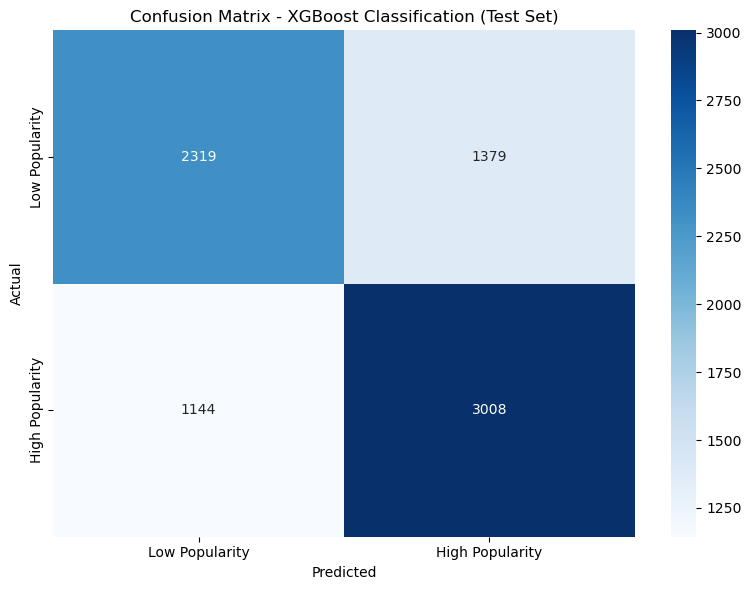

In [484]:
# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low Popularity', 'High Popularity'],
            yticklabels=['Low Popularity', 'High Popularity'])
plt.title('Confusion Matrix - XGBoost Classification (Test Set)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

#### TEST REGRESSION MODEL

Test Set R² Score: 0.0860
Test Set MAE: 1996.66
Test Set RMSE: 3578.67


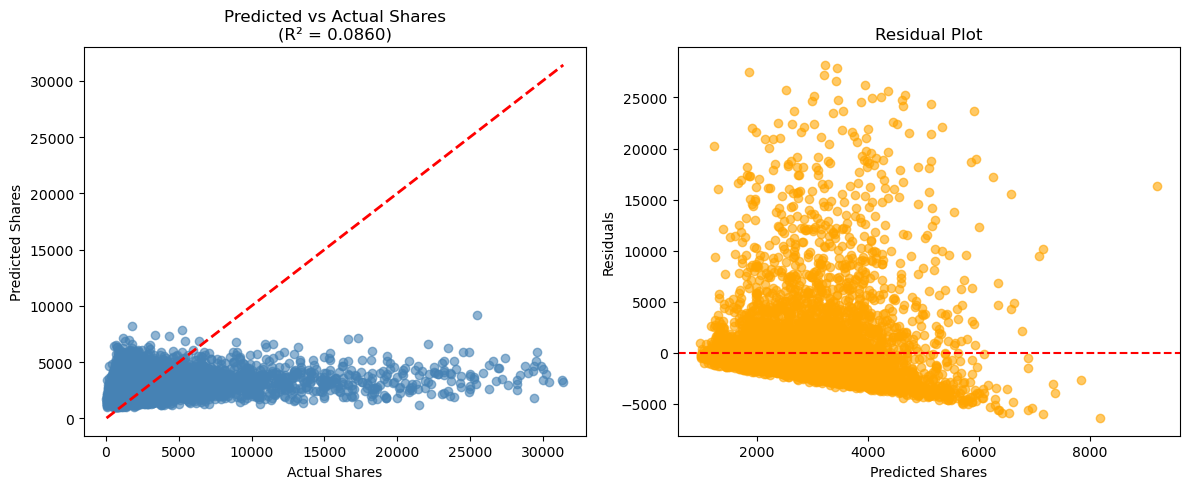

In [488]:
# TEST REGRESSION MODEL (Best: XGBoost Tuned - R² = 0.0860)

# Make predictions on test set
y_test_pred_reg = best_xgb_reg.predict(X_test)

# Calculate test metrics
test_r2 = r2_score(y_reg_test, y_test_pred_reg)
test_mae = mean_absolute_error(y_reg_test, y_test_pred_reg)
test_rmse = np.sqrt(mean_squared_error(y_reg_test, y_test_pred_reg))

print(f"Test Set R² Score: {test_r2:.4f}")
print(f"Test Set MAE: {test_mae:.2f}")
print(f"Test Set RMSE: {test_rmse:.2f}")

# Visualize predictions vs actual
plt.figure(figsize=(12, 5))

# Scatter plot of predictions vs actual
plt.subplot(1, 2, 1)
plt.scatter(y_reg_test, y_test_pred_reg, alpha=0.6, color='steelblue')
plt.plot([y_reg_test.min(), y_reg_test.max()], [y_reg_test.min(), y_reg_test.max()], 'r--', lw=2)
plt.xlabel('Actual Shares')
plt.ylabel('Predicted Shares')
plt.title(f'Predicted vs Actual Shares\n(R² = {test_r2:.4f})')

# Residual plot
plt.subplot(1, 2, 2)
residuals = y_reg_test - y_test_pred_reg
plt.scatter(y_test_pred_reg, residuals, alpha=0.6, color='orange')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Shares')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.tight_layout()
plt.show()

In [490]:
# MANUAL VALIDATION CHECK
# Select 10 random samples for manual inspection
np.random.seed(42)
random_indices = np.random.choice(len(X_test), 10, replace=False)

print("Random Sample Predictions vs Actual:")
print("=" * 80)
print(f"{'Index':<6} {'Actual Class':<12} {'Pred Class':<11} {'Actual Shares':<13} {'Pred Shares':<12} {'Status'}")
print("-" * 80)

for i, idx in enumerate(random_indices):
    actual_class = y_class_test.iloc[idx]
    pred_class = y_test_pred_class[idx]
    actual_shares = y_reg_test.iloc[idx]
    pred_shares = y_test_pred_reg[idx]
    
    # Check if classification is correct
    class_status = "✓" if actual_class == pred_class else "✗"
    
    print(f"{idx:<6} {actual_class:<12} {pred_class:<11} {actual_shares:<13.0f} {pred_shares:<12.0f} {class_status}")


Random Sample Predictions vs Actual:
Index  Actual Class Pred Class  Actual Shares Pred Shares  Status
--------------------------------------------------------------------------------
2057   0            1           1300          2026         ✗
6108   1            1           26900         4521         ✓
5717   0            0           614           2386         ✓
1346   1            0           13500         1715         ✗
601    1            1           2200          3241         ✓
7564   1            1           2400          2492         ✓
1087   1            0           26300         2661         ✗
2864   0            1           1200          7160         ✗
3404   0            0           695           3724         ✓
5702   1            1           4200          3382         ✓


Negative share predictions: 0 (should be 0)
Predicted shares range: 980 to 9210
Actual shares range: 35 to 31400


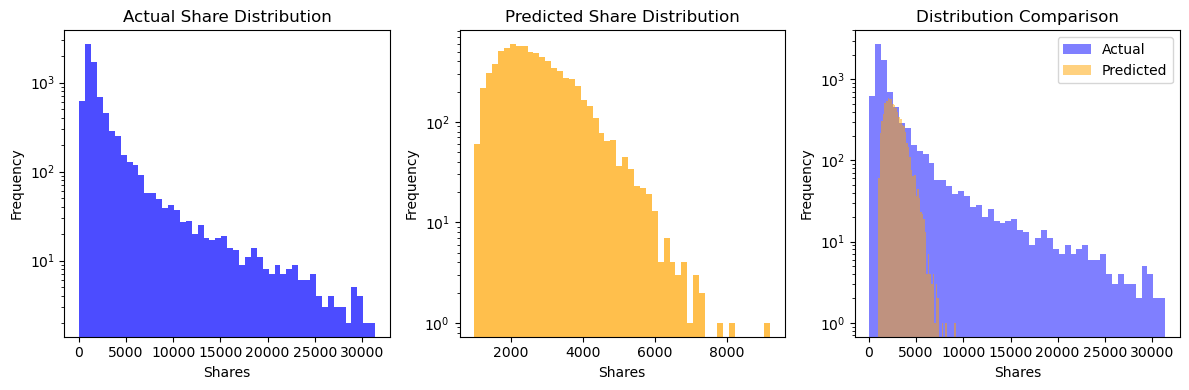

In [492]:
# PREDICTION SANITY CHECKS

# Check for negative predictions (shouldn't happen)
negative_preds = (y_test_pred_reg < 0).sum()
print(f"Negative share predictions: {negative_preds} (should be 0)")

# Check prediction ranges
print(f"Predicted shares range: {y_test_pred_reg.min():.0f} to {y_test_pred_reg.max():.0f}")
print(f"Actual shares range: {y_reg_test.min():.0f} to {y_reg_test.max():.0f}")

# Check prediction distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(y_reg_test, bins=50, alpha=0.7, label='Actual', color='blue')
plt.xlabel('Shares')
plt.ylabel('Frequency')
plt.title('Actual Share Distribution')
plt.yscale('log')

plt.subplot(1, 3, 2)
plt.hist(y_test_pred_reg, bins=50, alpha=0.7, label='Predicted', color='orange')
plt.xlabel('Shares')
plt.ylabel('Frequency')
plt.title('Predicted Share Distribution')
plt.yscale('log')

plt.subplot(1, 3, 3)
plt.hist(y_reg_test, bins=50, alpha=0.5, label='Actual', color='blue')
plt.hist(y_test_pred_reg, bins=50, alpha=0.5, label='Predicted', color='orange')
plt.xlabel('Shares')
plt.ylabel('Frequency')
plt.title('Distribution Comparison')
plt.legend()
plt.yscale('log')

plt.tight_layout()
plt.show()


In [500]:
# FINAL PERFORMANCE SUMMARY

print("CLASSIFICATION RESULTS:")
print(f"  Cross-Validation Accuracy: 68.14%")
print(f"  Test Set Accuracy: {test_accuracy*100:.2f}%")
print(f"  Performance Gap: {abs(68.14 - test_accuracy*100):.2f}%")

if abs(68.14 - test_accuracy*100) < 3.0:
    print("  Good generalization - small gap between CV and test")
else:
    print("   Large gap - possible overfitting")

print(f"\nREGRESSION RESULTS:")
print(f"  Cross-Validation R²: 0.0860")
print(f"  Test Set R²: {test_r2:.4f}")
print(f"  Performance Gap: {abs(0.0860 - test_r2):.4f}")

if abs(0.0860 - test_r2) < 0.02:
    print("  Consistent performance between CV and test")
else:
    print("   Performance difference noted")


CLASSIFICATION RESULTS:
  Cross-Validation Accuracy: 68.14%
  Test Set Accuracy: 67.86%
  Performance Gap: 0.28%
  Good generalization - small gap between CV and test

REGRESSION RESULTS:
  Cross-Validation R²: 0.0860
  Test Set R²: 0.0860
  Performance Gap: 0.0000
  Consistent performance between CV and test
